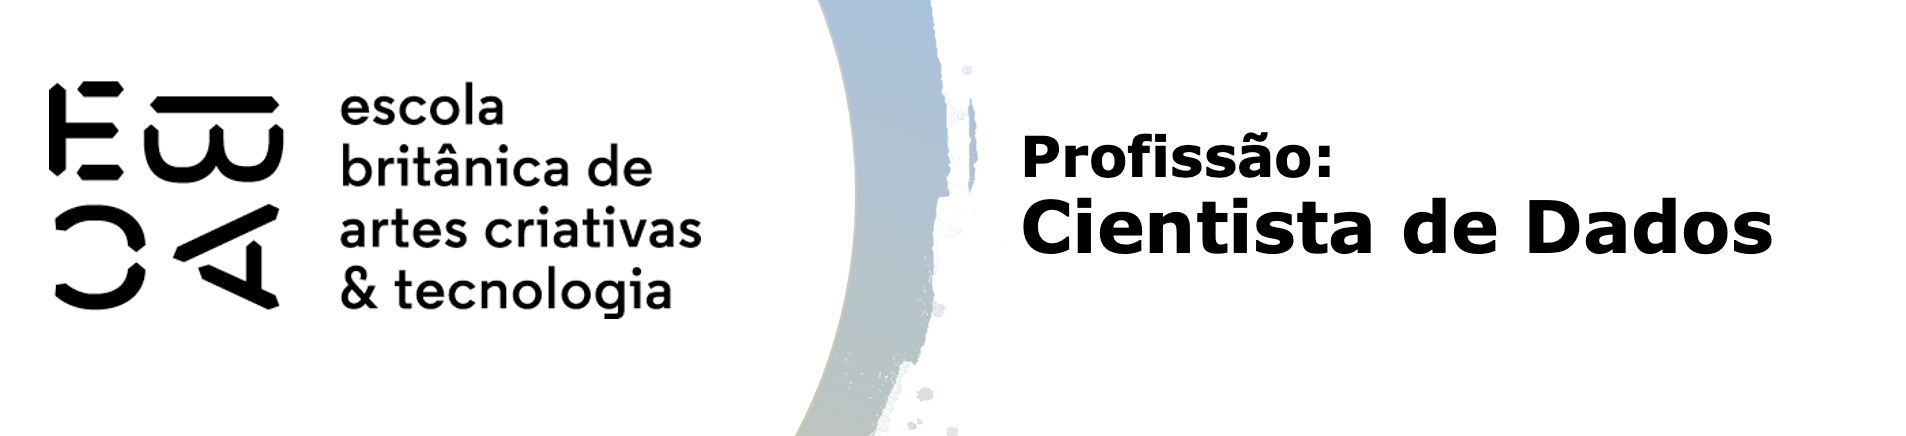

# Task

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

In [2]:
pg = sns.load_dataset('penguins')

pg.groupby('sex')['body_mass_g'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Female,165.0,3862.3,666.2,2700.0,3350.0,3650.0,4550.0,5200.0
Male,168.0,4545.7,787.6,3250.0,3900.0,4300.0,5312.5,6300.0


<AxesSubplot:xlabel='sex', ylabel='body_mass_g'>

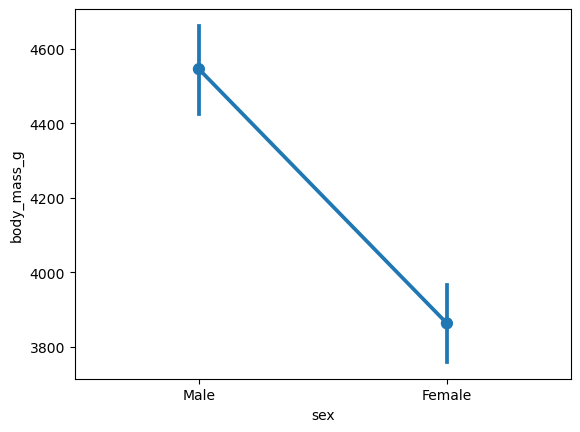

In [3]:
sns.pointplot(data=pg, x='sex', y = 'body_mass_g')

## 1) Weight difference between males and females

In the penguin base, we can see that there is a difference in weight between males and females. But is this a conclusion that can be extrapolated to the entire penguin population? Assuming that this sample is random and representative of the penguin population, perform a T test with 5% significance to see if we can induce this conclusion for the entire population.

In [4]:
male_mass = pg[pg['sex'] == 'Male']['body_mass_g']
female_mass = pg[pg['sex'] == 'Female']['body_mass_g']

# Perform two-sample t-test
t_statistic, p_value = ttest_ind(male_mass, female_mass)

alpha = 0.05

print("T-statistic: {:.1f}".format(t_statistic))
print("P-value: {:.4f}".format(p_value))

if p_value < alpha:
    print("- The difference in body mass between males and females is statistically significant at the 5% level.")
else:
    print("- There is not enough evidence to conclude that the difference in body mass between males and females is statistically significant at the 5% level.")

T-statistic: 8.5
P-value: 0.0000
- The difference in body mass between males and females is statistically significant at the 5% level.


## 2) (optional) Graphical representation of the test

Follow the steps in the class so you can visualize the test statistics, their distribution and the critical region of the test.

In [5]:
# Example: Calculate degrees of freedom for two-sample t-test
n1 = len(male_mass)
n2 = len(female_mass)
df = n1 + n2 - 2
print("Degrees of freedom:", df)

Degrees of freedom: 331


The probability for the values between -1.6 & inf is 95.05%


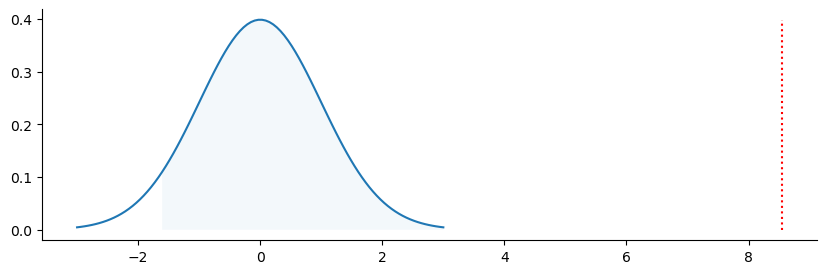

In [6]:
μ = 0
variance = 1
σ = variance ** .5

low = st.t.ppf(alpha, df)
high = np.inf

x = np.linspace(μ - 3*σ, μ + 3*σ, 100)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize = (10, 3))

ax.plot(x, y)
ax.vlines(x=[t_statistic],
          ymin = 0,
          ymax = y.max(),
          colors = 'r',
          linestyles = 'dotted')

plt.fill_between(x, y, where = (low < x) & (x < high), alpha = alpha)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

prob_area = st.norm.cdf(high, μ, σ) - st.norm.cdf(low,  μ, σ)
print(f'The probability for the values between {low:.1f} & {high:.1f} is {prob_area:.2%}')

- The 'low' value is returning -1.6:
> The critical value being -1.6 means that the critical region extends to the left, starting from -1.6 standard deviations away from the mean.

- The red dotted line lies on the 8.5 mark:
> This indicates that the t-statistic calculated from the data is significantly larger than the critical value obtained. A t-statistic of 8.5 indicates a very large difference between the means of Male and Female penguins body mass.

The critical value of -1.6 suggests a small threshold for statistical significance, contrasting with the notably large t-statistic of 8.5. This stark contrast indicates an exceptionally significant observed difference in body mass between male and female penguins, exceeding typical bounds for significance.

> In summary, these affirmations suggest that the observed difference in body mass between male and female penguins is extremely large, to the point that it is statistically significant even at very conservative levels of significance. The discrepancy between the t-statistic and the critical value indicates a strong evidence for rejecting the null hypothesis of no difference in body mass between male and female penguins.

## 3) Consider the species

Repeat task I, once for each species of penguin. What is the *p-value* associated with each breed?

In [7]:
species = pg['species'].unique()

for specie in species:
    male_mass2 = pg[(pg['species'] == specie) & (pg['sex'] == 'Male')]['body_mass_g']
    female_mass2 = pg[(pg['species'] == specie) & (pg['sex'] == 'Female')]['body_mass_g']
    
    t_statistic2, p_value2 = ttest_ind(male_mass2, female_mass2)
    
    print("Species:", specie)
    print("P-value: {:.4f}".format(p_value2))
    if p_value < alpha:
        print("- The difference in body mass between males and females is statistically significant at the 5% level.")
    else:
        print("- There is not enough evidence to conclude that the difference in body mass between males and females is statistically significant at the 5% level.")
    print()

Species: Adelie
P-value: 0.0000
- The difference in body mass between males and females is statistically significant at the 5% level.

Species: Chinstrap
P-value: 0.0000
- The difference in body mass between males and females is statistically significant at the 5% level.

Species: Gentoo
P-value: 0.0000
- The difference in body mass between males and females is statistically significant at the 5% level.

